In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create Dataset
data = {
    "student_id": [1,2,3,4,5,6,7,8,9,10],
    "student_name": ["Aman","Riya","John","Sara","Karan","Neha","Raj","Simran","Ali","Pooja"],
    "age": [20,21,19,22,20,23,21,20,22,19],
    "height": [170,165,180,175,169,172,300,168,171,167],  
    "weight": [65,55,70,68,60,72,150,58,62,59],         
    "semester": [3,4,2,5,3,6,4,3,5,2],
    "gender": ["M","F","M","F","M","F","M","F","M","F"],
    "city": ["Delhi","Mumbai","Delhi","Pune","Delhi","Mumbai","Delhi","Pune","Delhi","Mumbai"]
}

df = pd.DataFrame(data)
print(df)

   student_id student_name  age  height  weight  semester gender    city
0           1         Aman   20     170      65         3      M   Delhi
1           2         Riya   21     165      55         4      F  Mumbai
2           3         John   19     180      70         2      M   Delhi
3           4         Sara   22     175      68         5      F    Pune
4           5        Karan   20     169      60         3      M   Delhi
5           6         Neha   23     172      72         6      F  Mumbai
6           7          Raj   21     300     150         4      M   Delhi
7           8       Simran   20     168      58         3      F    Pune
8           9          Ali   22     171      62         5      M   Delhi
9          10        Pooja   19     167      59         2      F  Mumbai


In [3]:
print("Shape:", df.shape)


Shape: (10, 8)


In [4]:
print("Columns:", df.columns)


Columns: Index(['student_id', 'student_name', 'age', 'height', 'weight', 'semester',
       'gender', 'city'],
      dtype='object')


In [5]:
print("Null values:\n", df.isnull().sum())

Null values:
 student_id      0
student_name    0
age             0
height          0
weight          0
semester        0
gender          0
city            0
dtype: int64


In [6]:
print("Unique student names:", df["student_name"].unique())

Unique student names: ['Aman' 'Riya' 'John' 'Sara' 'Karan' 'Neha' 'Raj' 'Simran' 'Ali' 'Pooja']


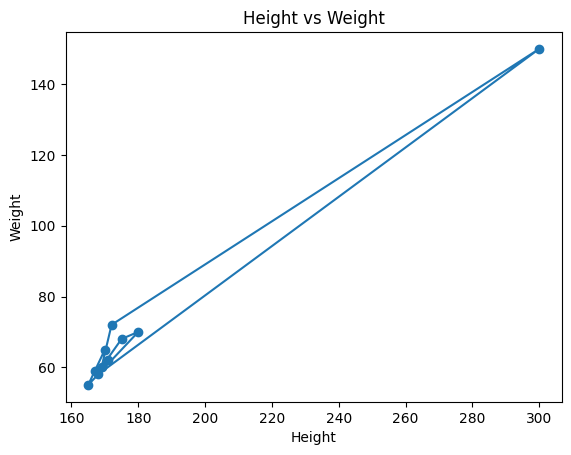

In [7]:
#  Line graphs between height and weight
plt.plot(df["height"], df["weight"], marker='o')
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")
plt.show()

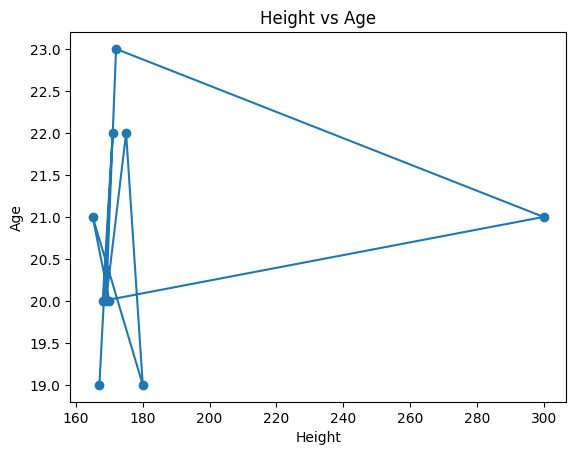

In [8]:
#  Line graphs between height and age 
plt.plot(df["height"], df["age"], marker='o')
plt.xlabel("Height")
plt.ylabel("Age")
plt.title("Height vs Age")
plt.show()


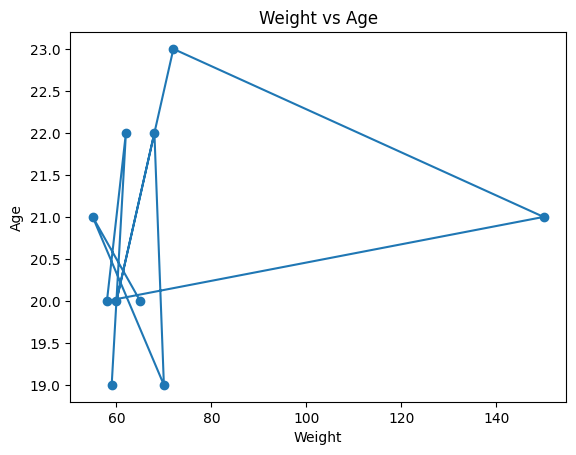

In [9]:
#  Line graphs between weight and age 
plt.plot(df["weight"], df["age"], marker='o')
plt.xlabel("Weight")
plt.ylabel("Age")
plt.title("Weight vs Age")
plt.show()


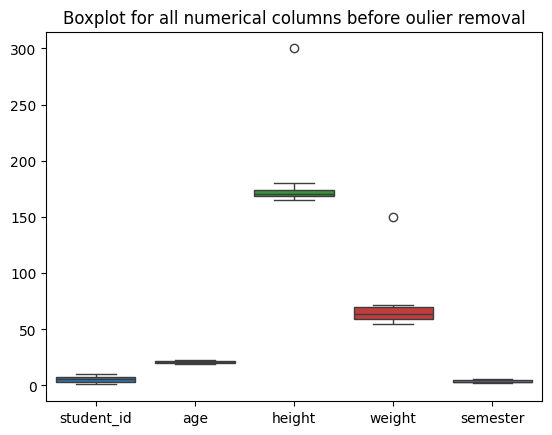

In [10]:
# Boxplot (outliers in all columns)
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot for all numerical columns before oulier removal")
plt.show()


In [16]:
# Remove outliers from height using IQR

Q1 = df["height"].quantile(0.25)
Q3 = df["height"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df= df[(df["height"] >= lower_bound) & (df["height"] <= upper_bound)]

print(df)


   student_id student_name  age  height  weight  semester gender    city
0           1         Aman   20     170      65         3      M   Delhi
1           2         Riya   21     165      55         4      F  Mumbai
3           4         Sara   22     175      68         5      F    Pune
4           5        Karan   20     169      60         3      M   Delhi
5           6         Neha   23     172      72         6      F  Mumbai
7           8       Simran   20     168      58         3      F    Pune
8           9          Ali   22     171      62         5      M   Delhi
9          10        Pooja   19     167      59         2      F  Mumbai


In [20]:

mean = df["weight"].mean()

std = df["weight"].std()

#  Z-score calculation 
df["z_score"] = (df["weight"] - mean) / std

df= df[np.abs(df["z_score"]) < 3]

print("\nAfter removing outliers:\n")
print(df)


After removing outliers:

   student_id student_name  age  height  weight  semester gender    city  \
0           1         Aman   20     170      65         3      M   Delhi   
1           2         Riya   21     165      55         4      F  Mumbai   
3           4         Sara   22     175      68         5      F    Pune   
4           5        Karan   20     169      60         3      M   Delhi   
5           6         Neha   23     172      72         6      F  Mumbai   
7           8       Simran   20     168      58         3      F    Pune   
8           9          Ali   22     171      62         5      M   Delhi   
9          10        Pooja   19     167      59         2      F  Mumbai   

    z_score  
0  0.466256  
1 -1.309956  
3  0.999119  
4 -0.421850  
5  1.709604  
7 -0.777093  
8 -0.066608  
9 -0.599472  


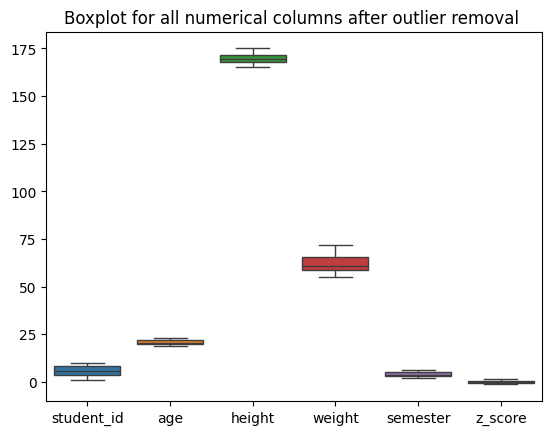

In [21]:
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot for all numerical columns after outlier removal ")
plt.show()